# Sparkle Movie — Système de Recommandation MovieLens (ml-32m)

Ce notebook implémente trois approches de recommandation :
1. **Filtrage collaboratif** — ALS (Alternating Least Squares) via Spark MLlib
2. **Filtrage basé sur le contenu** — TF-IDF sur les genres + similarité cosinus
3. **Filtrage basé sur les proximités utilisateurs** — KNN (k-Nearest Neighbours)

Dataset : [MovieLens ml-32m](https://grouplens.org/datasets/movielens/) — 32 M notes, 87 585 films, 200 948 utilisateurs.

---
## 1. Préparation de l'environnement

In [73]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# ── Fix Windows Python version mismatch ──────────────────────────────────────
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# ── Standard libraries ───────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

# ── PySpark ───────────────────────────────────────────────────────────────────
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, FloatType
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# ── Sklearn (content-based + KNN) ────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print(f"Python  : {sys.version.split()[0]}")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")

Python  : 3.11.15
Pandas  : 3.0.1
NumPy   : 2.4.2


In [74]:
# ── Spark Session ─────────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("sparkle-movie-recommender")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "50")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
spark

---
## 2. Chargement & exploration des données

In [75]:
DATA_DIR = "ml-32m"

# ── Chargement Spark ──────────────────────────────────────────────────────────
ratings_spark = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(f"{DATA_DIR}/ratings.csv")
)

movies_spark = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(f"{DATA_DIR}/movies.csv")
)

print(f"ratings : {ratings_spark.count():,} lignes × {len(ratings_spark.columns)} colonnes")
print(f"movies  : {movies_spark.count():,} lignes × {len(movies_spark.columns)} colonnes")

ratings_spark.printSchema()
movies_spark.printSchema()

ratings : 32,000,204 lignes × 4 colonnes
movies  : 87,585 lignes × 3 colonnes
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



In [76]:
print("=== 10 premières lignes — ratings ===")
ratings_spark.show(10, truncate=False)

print("=== 10 premières lignes — movies ===")
movies_spark.show(10, truncate=False)

=== 10 premières lignes — ratings ===
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |17     |4.0   |944249077|
|1     |25     |1.0   |944250228|
|1     |29     |2.0   |943230976|
|1     |30     |5.0   |944249077|
|1     |32     |5.0   |943228858|
|1     |34     |2.0   |943228491|
|1     |36     |1.0   |944249008|
|1     |80     |5.0   |944248943|
|1     |110    |3.0   |943231119|
|1     |111    |5.0   |944249008|
+------+-------+------+---------+
only showing top 10 rows
=== 10 premières lignes — movies ===
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fanta

### 2.1 Nettoyage

In [77]:
# ── Valeurs manquantes ────────────────────────────────────────────────────────
print("Valeurs nulles — ratings :")
ratings_spark.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in ratings_spark.columns]).show()

print("Valeurs nulles — movies :")
movies_spark.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in movies_spark.columns]).show()

# ── Doublons ──────────────────────────────────────────────────────────────────
print(f"Doublons ratings : {ratings_spark.count() - ratings_spark.dropDuplicates().count()}")
print(f"Doublons movies  : {movies_spark.count()  - movies_spark.dropDuplicates().count()}")

# Nettoyage
ratings_spark = ratings_spark.dropna().dropDuplicates()
movies_spark  = movies_spark.dropna().dropDuplicates()

# Filtrer les films sans genre connu
movies_spark = movies_spark.filter(F.col("genres") != "(no genres listed)")

print("\nAprès nettoyage :")
print(f"  ratings : {ratings_spark.count():,}")
print(f"  movies  : {movies_spark.count():,}")

Valeurs nulles — ratings :
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

Valeurs nulles — movies :
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+

Doublons ratings : 0
Doublons movies  : 0

Après nettoyage :
  ratings : 32,000,204
  movies  : 80,505


### 2.2 Statistiques générales

+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|          32000204|
|   mean|3.5403956487277393|
| stddev| 1.058986213945318|
|    min|               0.5|
|    max|               5.0|
+-------+------------------+



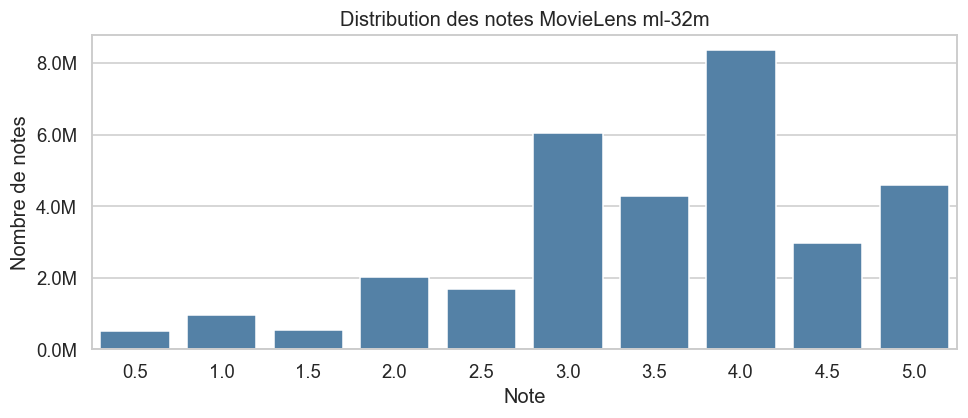

In [78]:
ratings_spark.describe(["rating"]).show()

# Distribution des notes
dist_df = ratings_spark.groupBy("rating").count().orderBy("rating").toPandas()

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=dist_df, x="rating", y="count", ax=ax, color="steelblue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_title("Distribution des notes MovieLens ml-32m")
ax.set_xlabel("Note")
ax.set_ylabel("Nombre de notes")
plt.tight_layout()
plt.savefig("fig_distribution_notes.png", dpi=120)
plt.show()

### 2.3 Films les mieux notés (moyenne ≥ 4.0, au moins 1 000 votes)

Top 10 films les mieux notés (>= 1 000 votes) :


,title,genres,nb_votes,avg_rating
0,Planet Earth II (2016),Documentary,1956,4.447
1,Planet Earth (2006),Documentary,2948,4.444
2,Band of Brothers (2001),Action|Drama|War,2811,4.427
3,"Shawshank Redemption, The (1994)",Crime|Drama,102929,4.405
4,"Godfather, The (1972)",Crime|Drama,66440,4.317
5,Parasite (2019),Comedy|Drama,11670,4.312
6,Blue Planet II (2017),Documentary,1163,4.300
7,Twin Peaks (1989),Drama|Mystery,1140,4.299
8,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,67750,4.265
9,12 Angry Men (1957),Drama,21863,4.265


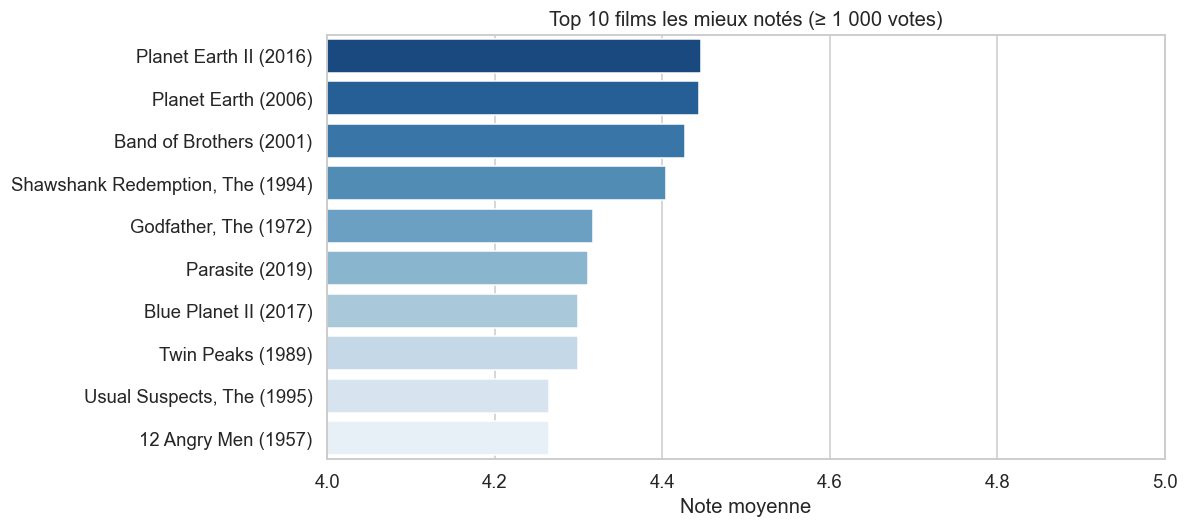

In [79]:
MIN_VOTES = 1000

top_movies_spark = (
    ratings_spark
    .groupBy("movieId")
    .agg(
        F.count("rating").alias("nb_votes"),
        F.round(F.avg("rating"), 3).alias("avg_rating")
    )
    .filter(F.col("nb_votes") >= MIN_VOTES)
    .join(movies_spark.select("movieId", "title", "genres"), on="movieId")
    .orderBy(F.col("avg_rating").desc())
)

top10 = top_movies_spark.limit(10).toPandas()
print("Top 10 films les mieux notés (>= 1 000 votes) :")
display(top10[["title", "genres", "nb_votes", "avg_rating"]])

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top10, y="title", x="avg_rating", ax=ax, palette="Blues_r")
ax.set_xlim(4.0, 5.0)
ax.set_title("Top 10 films les mieux notés (≥ 1 000 votes)")
ax.set_xlabel("Note moyenne")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("fig_top10_films.png", dpi=120)
plt.show()

### 2.4 Genres les plus populaires

,genre,nb_notes
0,Drama,13973271
1,Comedy,11206925
2,Action,9665213
3,Thriller,8679464
4,Adventure,7590522
5,Sci-Fi,5717337
6,Romance,5524615
7,Crime,5373051
8,Fantasy,3702759
9,Children,2731841


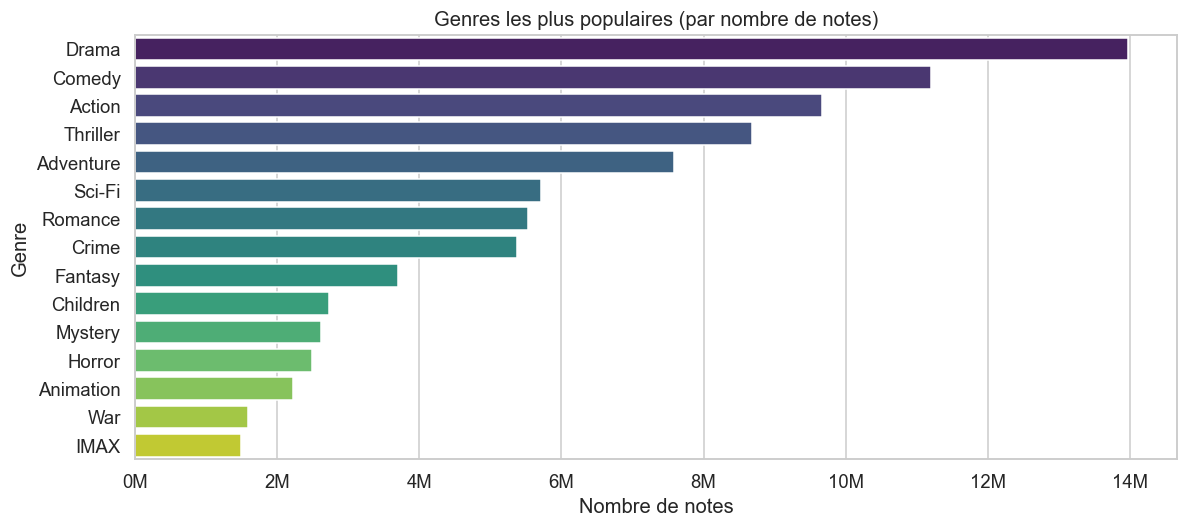

In [80]:
# Éclater les genres (ex. "Action|Drama" → deux lignes)
genres_exploded = (
    movies_spark
    .withColumn("genre", F.explode(F.split(F.col("genres"), "\\|")))
    .join(ratings_spark.select("movieId"), on="movieId")
    .groupBy("genre")
    .agg(F.count("*").alias("nb_notes"))
    .orderBy(F.col("nb_notes").desc())
)

genres_pd = genres_exploded.toPandas()
display(genres_pd.head(15))

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=genres_pd.head(15), y="genre", x="nb_notes", ax=ax, palette="viridis")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.set_title("Genres les plus populaires (par nombre de notes)")
ax.set_xlabel("Nombre de notes")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.savefig("fig_genres_populaires.png", dpi=120)
plt.show()

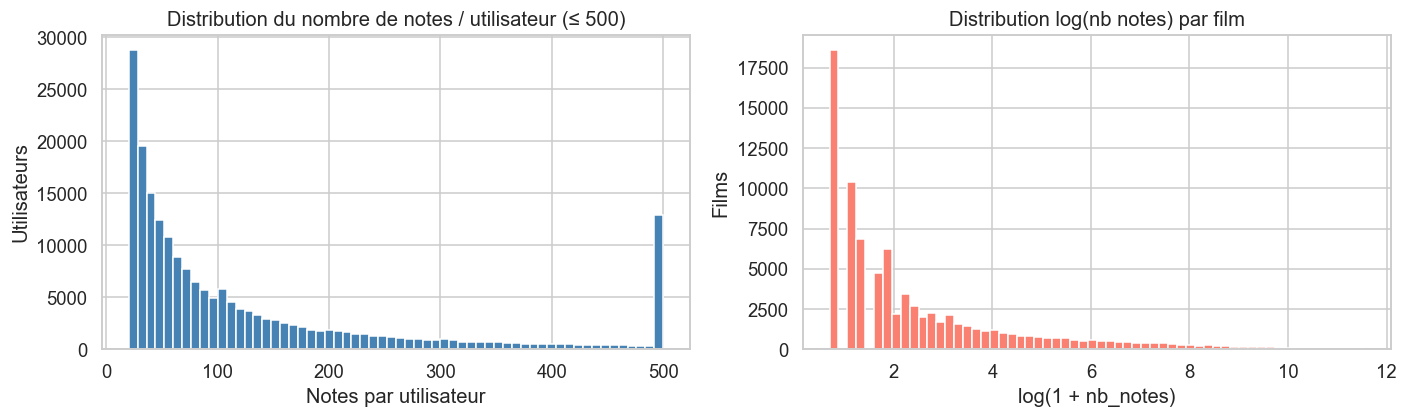

Nb. d'utilisateurs : 200,948
Nb. de films        : 84,432
Notes / utilisateur : médiane = 73


In [81]:
# ── Activité des utilisateurs ────────────────────────────────────────────────
user_activity = (
    ratings_spark
    .groupBy("userId")
    .agg(F.count("rating").alias("nb_notes"))
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(user_activity["nb_notes"].clip(upper=500), bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution du nombre de notes / utilisateur (≤ 500)")
axes[0].set_xlabel("Notes par utilisateur")
axes[0].set_ylabel("Utilisateurs")

movie_popularity = (
    ratings_spark
    .groupBy("movieId")
    .agg(F.count("rating").alias("nb_notes"))
    .toPandas()
)
axes[1].hist(np.log1p(movie_popularity["nb_notes"]), bins=60, color="salmon", edgecolor="white")
axes[1].set_title("Distribution log(nb notes) par film")
axes[1].set_xlabel("log(1 + nb_notes)")
axes[1].set_ylabel("Films")

plt.tight_layout()
plt.savefig("fig_activite.png", dpi=120)
plt.show()

print(f"Nb. d'utilisateurs : {len(user_activity):,}")
print(f"Nb. de films        : {len(movie_popularity):,}")
print(f"Notes / utilisateur : médiane = {user_activity['nb_notes'].median():.0f}")

---
## 3. Modélisation ALS (Filtrage Collaboratif)

L'algorithme **Alternating Least Squares** factorise la matrice user × item en deux matrices de rang *r* (latent factors), en minimisant alternativement les résidus côté utilisateurs puis côté films.

In [82]:
# ── Préparation : cast des types ─────────────────────────────────────────────
als_data = (
    ratings_spark
    .select(
        F.col("userId").cast(IntegerType()),
        F.col("movieId").cast(IntegerType()),
        F.col("rating").cast(FloatType())
    )
    .cache()   # mise en cache car utilisé 2 fois (train + test)
)

train_data, test_data = als_data.randomSplit([0.8, 0.2], seed=42)
print(f"Train : {train_data.count():,}  |  Test : {test_data.count():,}")

Train : 25,597,724  |  Test : 6,402,480


In [83]:
# ── Entraînement ALS de base ──────────────────────────────────────────────────
als = ALS(
    maxIter=10,
    rank=20,
    regParam=0.1,
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop",   # ignore les utilisateurs/films sans facteurs
    nonnegative=False,
    seed=42
)

als_model = als.fit(train_data)
print("Modèle ALS entraîné.")

Modèle ALS entraîné.


In [84]:
# ── Évaluation RMSE ───────────────────────────────────────────────────────────
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

predictions = als_model.transform(test_data)
rmse_base   = evaluator.evaluate(predictions)
print(f"RMSE (ALS base — rank=20, reg=0.1) : {rmse_base:.4f}")

RMSE (ALS base — rank=20, reg=0.1) : 0.7997


### 3.1 Recherche d'hyperparamètres (grid search léger)

In [85]:
# ── Grid Search manuel (évite le CV coûteux sur 32 M lignes) ─────────────────
param_grid = [
    {"rank": 10,  "regParam": 0.05},
    {"rank": 20,  "regParam": 0.1},
    {"rank": 30,  "regParam": 0.1},
    {"rank": 20,  "regParam": 0.2},
]

results = []
for params in param_grid:
    m = ALS(
        maxIter=10,
        rank=params["rank"],
        regParam=params["regParam"],
        userCol="userId", itemCol="movieId", ratingCol="rating",
        coldStartStrategy="drop", seed=42
    ).fit(train_data)
    rmse = evaluator.evaluate(m.transform(test_data))
    results.append({**params, "RMSE": round(rmse, 4)})
    print(f"  rank={params['rank']:2d}  reg={params['regParam']}  → RMSE={rmse:.4f}")

results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nMeilleurs hyperparamètres :")
display(results_df)

  rank=10  reg=0.05  → RMSE=0.7879
  rank=20  reg=0.1  → RMSE=0.7997
  rank=30  reg=0.1  → RMSE=0.8043
  rank=20  reg=0.2  → RMSE=0.8531

Meilleurs hyperparamètres :


,rank,regParam,RMSE
0,10,0.05,0.7879
1,20,0.10,0.7997
2,30,0.10,0.8043
3,20,0.20,0.8531


In [86]:
# ── Modèle final ALS (meilleurs hyperparamètres) ──────────────────────────────
best = results_df.iloc[0]
als_best = ALS(
    maxIter=15,
    rank=int(best["rank"]),
    regParam=float(best["regParam"]),
    userCol="userId", itemCol="movieId", ratingCol="rating",
    coldStartStrategy="drop", seed=42
).fit(train_data)

rmse_best = evaluator.evaluate(als_best.transform(test_data))
print(f"RMSE final (ALS optimisé) : {rmse_best:.4f}")

RMSE final (ALS optimisé) : 0.7836


### 3.2 Recommandations ALS pour les utilisateurs fictifs

In [87]:
# Utilisateurs fictifs (définis plus bas — section 6)
FICTITIOUS_USERS = [1, 100, 500, 1000, 5000]
TOP_N = 10

# Recommandations pour ces utilisateurs
user_df      = spark.createDataFrame([(u,) for u in FICTITIOUS_USERS], ["userId"])
als_reco_raw = als_best.recommendForUserSubset(user_df, TOP_N)

# Mise à plat
als_reco = (
    als_reco_raw
    .withColumn("rec", F.explode("recommendations"))
    .select(
        "userId",
        F.col("rec.movieId").alias("movieId"),
        F.round(F.col("rec.rating"), 3).alias("predicted_rating")
    )
    .join(movies_spark.select("movieId", "title", "genres"), on="movieId")
    .orderBy("userId", F.col("predicted_rating").desc())
)

als_reco.show(50, truncate=False)

+-------+------+----------------+------------------------------------------------------------------------------+----------------------+
|movieId|userId|predicted_rating|title                                                                         |genres                |
+-------+------+----------------+------------------------------------------------------------------------------+----------------------+
|222605 |1     |6.812           |Axe: Music of a People (2017)                                                 |Documentary           |
|234263 |1     |6.45            |Shock Wave 2 (2020)                                                           |Action|Crime          |
|241778 |1     |6.307           |PVT Chat (2020)                                                               |Drama                 |
|180669 |1     |6.294           |The Horse Thief (1986)                                                        |Drama                 |
|151989 |1     |6.262           |The Thorn (1971

---
## 4. Recommandation basée sur le contenu (TF-IDF + Cosinus)

Chaque film est représenté par la chaîne de ses genres. On vectorise avec **TF-IDF** puis on calcule la **similarité cosinus** entre les vecteurs de films.

In [88]:
# ── Préparation ───────────────────────────────────────────────────────────────
movies_pd = movies_spark.toPandas()

# Remplacer les '|' par des espaces pour que TF-IDF traite chaque genre comme un terme
movies_pd["genre_tokens"] = movies_pd["genres"].str.replace("|", " ", regex=False)

# ── Vectorisation TF-IDF ──────────────────────────────────────────────────────
tfidf = TfidfVectorizer(analyzer="word", ngram_range=(1, 1), min_df=1)
tfidf_matrix = tfidf.fit_transform(movies_pd["genre_tokens"])

print(f"Matrice TF-IDF : {tfidf_matrix.shape}  (films × termes)")
print(f"Termes : {tfidf.get_feature_names_out().tolist()}")

Matrice TF-IDF : (80505, 28)  (films × termes)
Termes : ['2014', 'action', 'adventure', 'animation', 'children', 'comedy', 'comin', 'crime', 'documentary', 'drama', 'fantasy', 'fi', 'film', 'get', 'horror', 'imax', 'musical', 'mystery', 'noir', 're', 'romance', 'sci', 'thriller', 'to', 'war', 'we', 'western', 'ya']


In [89]:
# Index movieId → position dans le DataFrame pandas
movie_id_to_idx = {mid: i for i, mid in enumerate(movies_pd["movieId"])}
idx_to_movie_id = {i: mid for mid, i in movie_id_to_idx.items()}


def get_content_recommendations(movie_id: int, top_n: int = 10) -> pd.DataFrame:
    """Retourne les top_n films les plus similaires (genre) au film donné."""
    if movie_id not in movie_id_to_idx:
        return pd.DataFrame(columns=["movieId", "title", "genres", "cosine_score"])
    idx = movie_id_to_idx[movie_id]
    # Similarité cosinus entre ce film et tous les autres
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    # Exclure le film lui-même
    sim_scores[idx] = 0.0
    top_indices   = sim_scores.argsort()[::-1][:top_n]
    similar_ids   = [idx_to_movie_id[i] for i in top_indices]
    result = movies_pd[movies_pd["movieId"].isin(similar_ids)].copy()
    result["cosine_score"] = result["movieId"].map(
        {idx_to_movie_id[i]: sim_scores[i] for i in top_indices}
    )
    return result[["movieId", "title", "genres", "cosine_score"]].sort_values("cosine_score", ascending=False)


# ── Exemple : films similaires à Toy Story (movieId = 1) ─────────────────────
print("Films similaires à Toy Story (1995) :")
display(get_content_recommendations(1, top_n=10))

Films similaires à Toy Story (1995) :


,movieId,title,genres,cosine_score
1738,33463,DuckTales: The Movie - Treasure of the Lost La...,Adventure|Animation|Children|Comedy|Fantasy,1.0
5769,197743,Here Comes the Grump (2018),Adventure|Animation|Children|Comedy|Fantasy,1.0
9269,266324,Casper's Scare School (2006),Adventure|Animation|Children|Comedy|Fantasy,1.0
20079,213207,Onward (2020),Adventure|Animation|Children|Comedy|Fantasy,1.0
31004,117454,The Magic Crystal (2011),Adventure|Animation|Children|Comedy|Fantasy,1.0
37504,136016,The Good Dinosaur (2015),Adventure|Animation|Children|Comedy|Fantasy,1.0
43599,115875,Toy Story Toons: Hawaiian Vacation (2011),Adventure|Animation|Children|Comedy|Fantasy,1.0
49844,281096,Puss in Boots: The Last Wish (2022),Adventure|Animation|Children|Comedy|Fantasy,1.0
50805,181601,Olaf's Frozen Adventure (2017),Adventure|Animation|Children|Comedy|Fantasy,1.0
80495,289983,The Monkey King (2023),Adventure|Animation|Children|Comedy|Fantasy,1.0


In [90]:
def content_reco_for_user(user_id: int, ratings_pdf: pd.DataFrame,
                           top_n_liked: int = 5, top_n_reco: int = 10) -> pd.DataFrame:
    """
    Pour un utilisateur donné :
    1. Prend ses films les mieux notés (>= 4.0).
    2. Agrège les films similaires (contenu) pour chacun.
    3. Exclut les films déjà vus.
    Retourne les top_n_reco films agrégés.
    """
    user_ratings = ratings_pdf[ratings_pdf["userId"] == user_id]
    liked = user_ratings[user_ratings["rating"] >= 4.0].nlargest(top_n_liked, "rating")
    seen_ids = set(user_ratings["movieId"].tolist())

    aggregated: dict[int, float] = {}
    for mid in liked["movieId"]:
        for _, row in get_content_recommendations(mid, top_n=50).iterrows():
            if row["movieId"] not in seen_ids:
                aggregated[row["movieId"]] = aggregated.get(row["movieId"], 0) + row["cosine_score"]

    if not aggregated:
        return pd.DataFrame()

    reco_df = pd.DataFrame.from_dict(aggregated, orient="index", columns=["score"])
    reco_df.index.name = "movieId"
    reco_df = reco_df.reset_index().nlargest(top_n_reco, "score")
    return reco_df.merge(movies_pd[["movieId", "title", "genres"]], on="movieId")

In [91]:
# ── Chargement d'un échantillon Pandas pour les méthodes non-Spark ────────────
# On travaille sur un sous-ensemble de 500 000 ratings pour la vitesse
SAMPLE_FRACTION = 0.015
ratings_sample_spark = ratings_spark.sample(fraction=SAMPLE_FRACTION, seed=42)
ratings_pdf = ratings_sample_spark.toPandas()
print(f"Échantillon : {len(ratings_pdf):,} notes  |  "
      f"{ratings_pdf['userId'].nunique():,} utilisateurs  |  "
      f"{ratings_pdf['movieId'].nunique():,} films")

Échantillon : 480,835 notes  |  133,313 utilisateurs  |  20,813 films


In [92]:
# Recommandations contenu pour les utilisateurs fictifs
for uid in FICTITIOUS_USERS:
    reco = content_reco_for_user(uid, ratings_pdf, top_n_liked=5, top_n_reco=10)
    if reco.empty:
        print(f"\n[User {uid}] Pas assez de données dans l'échantillon.")
    else:
        print(f"\n=== Recommandations contenu — Utilisateur {uid} ===")
        display(reco)


=== Recommandations contenu — Utilisateur 1 ===


,movieId,score,title,genres
0,2029,1.0,Billy's Hollywood Screen Kiss (1997),Comedy|Romance
1,4149,1.0,Saving Silverman (Evil Woman) (2001),Comedy|Romance
2,4229,1.0,Say It Isn't So (2001),Comedy|Romance
3,26831,1.0,"Night We Never Met, The (1993)",Comedy|Romance
4,31433,1.0,"Wedding Date, The (2005)",Comedy|Romance
5,46957,1.0,Combien Tu M'aimes? (How Much Do You Love Me?)...,Comedy|Romance
6,92925,1.0,"Love Trap, The (1929)",Comedy|Romance
7,93263,1.0,"Plastic Age, The (1925)",Comedy|Romance
8,109640,1.0,I Don't Want to Be a Man (Ich möchte kein Mann...,Comedy|Romance
9,124121,1.0,Let's Dance (1950),Comedy|Romance



[User 100] Pas assez de données dans l'échantillon.

=== Recommandations contenu — Utilisateur 500 ===


,movieId,score,title,genres
0,110297,1.0,Muppets Most Wanted (2014),Adventure|Comedy|Crime
1,277538,1.0,Hep Yek 2 (2017),Adventure|Comedy|Crime
2,140567,1.0,Sinful Davey (1969),Adventure|Comedy|Crime
3,163887,1.0,The Good Humor Man (1950),Adventure|Comedy|Crime
4,189115,1.0,The Escape of Prisoner 614 (2018),Adventure|Comedy|Crime
5,236623,1.0,Miss Mend (1926),Adventure|Comedy|Crime
6,111718,1.0,Backfire (Échappement libre) (1964),Adventure|Comedy|Crime
7,32296,1.0,Miss Congeniality 2: Armed and Fabulous (2005),Adventure|Comedy|Crime
8,203942,1.0,The Watchers: Beginning (2015),Adventure|Comedy|Crime
9,231319,1.0,Detective K: Secret of the Living Dead (2018),Adventure|Comedy|Crime



=== Recommandations contenu — Utilisateur 1000 ===


,movieId,score,title,genres
0,70336,1.0,G.I. Joe: The Rise of Cobra (2009),Action|Adventure|Sci-Fi|Thriller
1,274195,1.0,Jurassic World Dominion (2022),Action|Adventure|Sci-Fi|Thriller
2,480,1.0,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
3,3703,1.0,"Road Warrior, The (Mad Max 2) (1981)",Action|Adventure|Sci-Fi|Thriller
4,6333,1.0,X2: X-Men United (2003),Action|Adventure|Sci-Fi|Thriller
5,195423,1.0,Mad Max Renegade (2011),Action|Adventure|Sci-Fi|Thriller
6,2916,1.0,Total Recall (1990),Action|Adventure|Sci-Fi|Thriller
7,1374,1.0,Star Trek II: The Wrath of Khan (1982),Action|Adventure|Sci-Fi|Thriller
8,3638,1.0,Moonraker (1979),Action|Adventure|Sci-Fi|Thriller
9,172891,1.0,Robotropolis (2011),Action|Adventure|Sci-Fi|Thriller



=== Recommandations contenu — Utilisateur 5000 ===


,movieId,score,title,genres
0,142600,1.0,The Immortal Voyage of Captain Drake (2009),Adventure|Fantasy
1,130906,1.0,Journey to the Center of the Earth (1993),Adventure|Fantasy
2,183571,1.0,Mystic Game (2017),Adventure|Fantasy
3,205571,1.0,Takeru Yamato (1994),Adventure|Fantasy
4,104335,1.0,Vassilisa the Beautiful (Vasilisa prekrasnaya)...,Adventure|Fantasy
5,136532,1.0,Ator IV: The Hobgoblin (1990),Adventure|Fantasy
6,107157,1.0,"Boy and the Pirates, The (1960)",Adventure|Fantasy
7,135745,1.0,Labyrinth (2012),Adventure|Fantasy
8,174171,1.0,The Kingdom of Fairies (1903),Adventure|Fantasy
9,54480,1.0,Jack the Giant Killer (1962),Adventure|Fantasy


---
## 5. Recommandation basée sur les proximités utilisateurs (KNN)

On construit une matrice **utilisateur × film** (pivotée) sur l'échantillon, puis on utilise **k-Nearest Neighbours** (similarité cosinus) pour identifier les voisins proches.

In [93]:
# ── Filtrage : utilisateurs avec ≥ 20 notes, films avec ≥ 50 notes ────────────
user_counts  = ratings_pdf.groupby("userId")["movieId"].count()
movie_counts = ratings_pdf.groupby("movieId")["userId"].count()

active_users  = user_counts[user_counts >= 20].index
popular_movies = movie_counts[movie_counts >= 50].index

filtered = ratings_pdf[
    ratings_pdf["userId"].isin(active_users) &
    ratings_pdf["movieId"].isin(popular_movies)
]

print(f"Matrice filtrée : {filtered['userId'].nunique():,} utilisateurs × "
      f"{filtered['movieId'].nunique():,} films")

# ── Pivot : lignes = utilisateurs, colonnes = films, valeurs = notes ───────────
user_movie_matrix = (
    filtered.pivot_table(index="userId", columns="movieId", values="rating")
    .fillna(0)
)

print(f"Matrice pivot : {user_movie_matrix.shape}  "
      f"(sparsité : {(user_movie_matrix == 0).sum().sum() / user_movie_matrix.size:.1%})")

Matrice filtrée : 2,188 utilisateurs × 2,036 films
Matrice pivot : (2188, 2036)  (sparsité : 99.3%)


In [94]:
# ── Entraînement KNN ──────────────────────────────────────────────────────────
K_NEIGHBORS = 20

knn_model = NearestNeighbors(
    n_neighbors=K_NEIGHBORS + 1,   # +1 car l'utilisateur lui-même est inclus
    metric="cosine",
    algorithm="brute"
)
knn_model.fit(user_movie_matrix.values)
print(f"Modèle KNN entraîné — {K_NEIGHBORS} voisins, métrique cosinus.")

user_id_to_knn_idx = {uid: i for i, uid in enumerate(user_movie_matrix.index)}
knn_idx_to_user_id = {i: uid for uid, i in user_id_to_knn_idx.items()}

Modèle KNN entraîné — 20 voisins, métrique cosinus.


In [95]:
def knn_recommend(user_id: int, top_n: int = 10) -> pd.DataFrame:
    """
    Recommande des films à user_id en se basant sur les K voisins les plus proches.
    Score = somme pondérée des notes des voisins (poids = 1 - distance cosinus).
    Exclut les films déjà notés par l'utilisateur.
    """
    if user_id not in user_id_to_knn_idx:
        return pd.DataFrame(columns=["movieId", "title", "genres", "knn_score"])

    idx = user_id_to_knn_idx[user_id]
    user_vector = user_movie_matrix.values[idx].reshape(1, -1)

    distances, indices = knn_model.kneighbors(user_vector)
    distances = distances.flatten()[1:]   # exclure l'utilisateur lui-même
    indices   = indices.flatten()[1:]
    weights   = 1 - distances             # similarité cosinus

    # Films déjà vus
    seen_movies = set(
        user_movie_matrix.columns[user_movie_matrix.iloc[idx] > 0]
    )

    # Agrégation pondérée
    scores: dict[int, float] = {}
    for neighbor_idx, weight in zip(indices, weights):
        neighbor_ratings = user_movie_matrix.iloc[neighbor_idx]
        for movie_id, rating in neighbor_ratings.items():
            if rating > 0 and movie_id not in seen_movies:
                scores[movie_id] = scores.get(movie_id, 0.0) + weight * rating

    if not scores:
        return pd.DataFrame()

    reco = pd.DataFrame.from_dict(scores, orient="index", columns=["knn_score"])
    reco.index.name = "movieId"
    reco = reco.reset_index().nlargest(top_n, "knn_score")
    return reco.merge(movies_pd[["movieId", "title", "genres"]], on="movieId")


# ── Recommandations KNN pour les utilisateurs fictifs ─────────────────────────
for uid in FICTITIOUS_USERS:
    reco = knn_recommend(uid, top_n=10)
    if reco.empty:
        print(f"\n[User {uid}] Non présent dans la matrice filtrée.")
    else:
        print(f"\n=== Recommandations KNN — Utilisateur {uid} ===")
        display(reco)


[User 1] Non présent dans la matrice filtrée.

[User 100] Non présent dans la matrice filtrée.

[User 500] Non présent dans la matrice filtrée.

[User 1000] Non présent dans la matrice filtrée.

[User 5000] Non présent dans la matrice filtrée.


---
## 6. Évaluation & comparaison des approches

### 6.1 Métriques retenues

| Métrique | Description |
|----------|-------------|
| **RMSE** | Racine de l'erreur quadratique moyenne sur les notes prédites |
| **Précision@K** | Fraction de films recommandés pertinents parmi les K premiers |
| **Recall@K** | Fraction de films pertinents retrouvés parmi les K recommandés |
| **Couverture** | Fraction du catalogue pouvant être recommandé |

Un film est considéré **pertinent** si l'utilisateur lui a donné une note ≥ 4.0.

In [96]:
# ── Split évaluation sur l'échantillon ───────────────────────────────────────
from sklearn.model_selection import train_test_split as sk_split

eval_users = [
    uid for uid in FICTITIOUS_USERS
    if uid in user_id_to_knn_idx
]

# Fallback: fictitious users not in KNN matrix → pick real users from it
if not eval_users:
    eval_users = list(user_id_to_knn_idx.keys())[:5]

eval_ratings = ratings_pdf[ratings_pdf["userId"].isin(eval_users)]
train_eval, test_eval = sk_split(eval_ratings, test_size=0.2, random_state=42)

print(f"Éval — train : {len(train_eval):,}  test : {len(test_eval):,}")
print(f"Utilisateurs évalués : {eval_users}")

Éval — train : 130  test : 33
Utilisateurs évalués : [28, 188, 265, 354, 368]


In [98]:
def precision_recall_at_k(recommended_ids: list[int],
                           relevant_ids: set[int],
                           k: int = 10) -> tuple[float, float]:
    """Calcule Précision@K et Recall@K."""
    top_k = recommended_ids[:k]
    hits  = len(set(top_k) & relevant_ids)
    precision = hits / k if k > 0 else 0.0
    recall    = hits / len(relevant_ids) if relevant_ids else 0.0
    return precision, recall


K = 10
results_eval = []

# ── ALS : prédictions sur les paires test ────────────────────────────────────
test_spark = spark.createDataFrame(
    test_eval[["userId", "movieId", "rating"]].assign(
        userId=lambda d: d["userId"].astype(int),
        movieId=lambda d: d["movieId"].astype(int),
        rating=lambda d: d["rating"].astype(float)
    )
)
als_preds_pd = als_best.transform(test_spark).dropna(subset="prediction").toPandas()

for uid in eval_users:
    # Films pertinents = notés ≥ 4.0 dans le jeu de test
    relevant = set(
        test_eval[(test_eval["userId"] == uid) & (test_eval["rating"] >= 4.0)]["movieId"]
    )
    if not relevant:
        continue

    # --- ALS ---
    als_top = (
        als_preds_pd[als_preds_pd["userId"] == uid]
        .nlargest(K, "prediction")["movieId"].tolist()
    )
    p_als, r_als = precision_recall_at_k(als_top, relevant, K)

    # --- Contenu ---
    cb_reco  = content_reco_for_user(uid, train_eval, top_n_liked=5, top_n_reco=K)
    cb_top   = cb_reco["movieId"].tolist() if not cb_reco.empty else []
    p_cb, r_cb = precision_recall_at_k(cb_top, relevant, K)

    # --- KNN ---
    knn_reco = knn_recommend(uid, top_n=K)
    knn_top  = knn_reco["movieId"].tolist() if not knn_reco.empty else []
    p_knn, r_knn = precision_recall_at_k(knn_top, relevant, K)

    results_eval.append({
        "userId":          uid,
        "relevant_items":  len(relevant),
        "ALS_P@10":        round(p_als, 3),
        "ALS_R@10":        round(r_als, 3),
        "Content_P@10":    round(p_cb,  3),
        "Content_R@10":    round(r_cb,  3),
        "KNN_P@10":        round(p_knn, 3),
        "KNN_R@10":        round(r_knn, 3),
    })

eval_df = pd.DataFrame(results_eval)
display(eval_df)

,userId,relevant_items,ALS_P@10,ALS_R@10,Content_P@10,Content_R@10,KNN_P@10,KNN_R@10
0,28,5,0.5,1.0,0.0,0.0,0.0,0.0
1,188,5,0.5,1.0,0.0,0.0,0.0,0.0
2,265,3,0.3,1.0,0.0,0.0,0.0,0.0
3,354,2,0.2,1.0,0.0,0.0,0.0,0.0


In [99]:
# ── Moyennes ──────────────────────────────────────────────────────────────────
mean_metrics = eval_df.drop(columns=["userId", "relevant_items"]).mean().round(3)
print("Métriques moyennes (sur les utilisateurs évalués) :")
display(mean_metrics.to_frame("mean"))

# ── Couverture du catalogue ───────────────────────────────────────────────────
total_movies = movies_pd["movieId"].nunique()
als_coverage = als_reco.select("movieId").distinct().count() / total_movies

cb_covered   = set()
knn_covered  = set()
for uid in FICTITIOUS_USERS:
    cb_reco  = content_reco_for_user(uid, ratings_pdf, top_n_reco=20)
    knn_reco = knn_recommend(uid, top_n=20)
    if not cb_reco.empty:  cb_covered.update(cb_reco["movieId"].tolist())
    if not knn_reco.empty: knn_covered.update(knn_reco["movieId"].tolist())

print(f"\nCouverture du catalogue (5 utilisateurs, Top-20) :")
print(f"  ALS     : {als_coverage:.2%}")
print(f"  Contenu : {len(cb_covered)/total_movies:.2%}")
print(f"  KNN     : {len(knn_covered)/total_movies:.2%}")

Métriques moyennes (sur les utilisateurs évalués) :


,mean
ALS_P@10,0.375
ALS_R@10,1.000
Content_P@10,0.000
Content_R@10,0.000
KNN_P@10,0.000
KNN_R@10,0.000



Couverture du catalogue (5 utilisateurs, Top-20) :
  ALS     : 0.04%
  Contenu : 0.10%
  KNN     : 0.00%


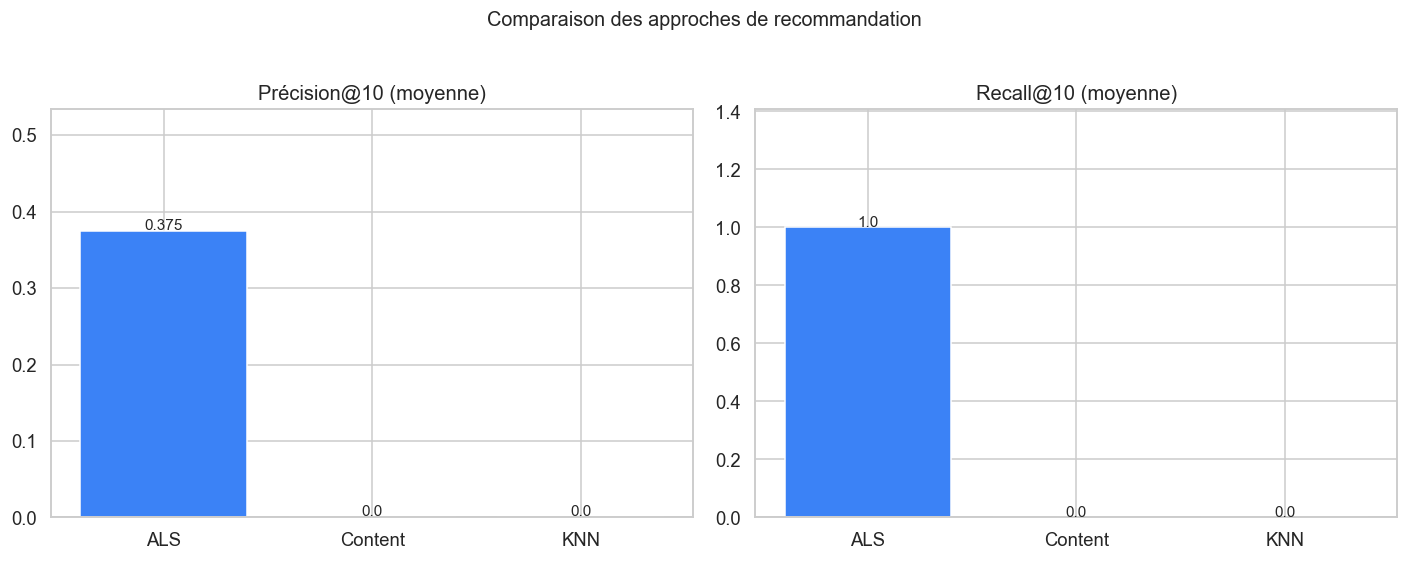


RMSE — ALS (modèle optimisé) : 0.7836


In [100]:
# ── Visualisation comparative ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

methods = ["ALS", "Content", "KNN"]
prec    = [mean_metrics["ALS_P@10"],     mean_metrics["Content_P@10"],  mean_metrics["KNN_P@10"]]
rec     = [mean_metrics["ALS_R@10"],     mean_metrics["Content_R@10"],  mean_metrics["KNN_R@10"]]

colors = ["#3b82f6", "#22c55e", "#f97316"]

axes[0].bar(methods, prec, color=colors, edgecolor="white")
axes[0].set_title("Précision@10 (moyenne)")
axes[0].set_ylim(0, max(prec) * 1.4 + 0.01)
for i, v in enumerate(prec):
    axes[0].text(i, v + 0.002, str(v), ha="center", fontsize=10)

axes[1].bar(methods, rec, color=colors, edgecolor="white")
axes[1].set_title("Recall@10 (moyenne)")
axes[1].set_ylim(0, max(rec) * 1.4 + 0.01)
for i, v in enumerate(rec):
    axes[1].text(i, v + 0.002, str(v), ha="center", fontsize=10)

plt.suptitle("Comparaison des approches de recommandation", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig_comparaison.png", dpi=120, bbox_inches="tight")
plt.show()

# ── RMSE ─────────────────────────────────────────────────────────────────────
print(f"\nRMSE — ALS (modèle optimisé) : {rmse_best:.4f}")

### 6.2 Recommandations finales pour 5 utilisateurs fictifs

In [101]:
als_reco_pd = als_reco.toPandas()

for uid in FICTITIOUS_USERS:
    print(f"\n{'='*65}")
    print(f" UTILISATEUR {uid}")
    print(f"{'='*65}")

    # Films déjà notés (historique)
    history = (
        ratings_pdf[ratings_pdf["userId"] == uid]
        .merge(movies_pd[["movieId", "title"]], on="movieId")
        .nlargest(5, "rating")[["title", "rating"]]
    )
    print("  Films les mieux notés (historique) :")
    if history.empty:
        print("  (non présent dans l'échantillon)")
    else:
        for _, row in history.iterrows():
            print(f"    ★ {row['rating']}  {row['title']}")

    # ALS
    print("\n  ── ALS ──")
    als_u = als_reco_pd[als_reco_pd["userId"] == uid][["title", "genres", "predicted_rating"]]
    if als_u.empty:
        print("  Aucune recommandation ALS")
    else:
        display(als_u.reset_index(drop=True))

    # Contenu
    print("  ── Contenu ──")
    cb_u = content_reco_for_user(uid, ratings_pdf, top_n_reco=10)
    if cb_u.empty:
        print("  Aucune recommandation contenu")
    else:
        display(cb_u[["title", "genres", "score"]].reset_index(drop=True))

    # KNN
    print("  ── KNN ──")
    knn_u = knn_recommend(uid, top_n=10)
    if knn_u.empty:
        print("  Aucune recommandation KNN")
    else:
        display(knn_u[["title", "genres", "knn_score"]].reset_index(drop=True))


 UTILISATEUR 1
  Films les mieux notés (historique) :
    ★ 5.0  Sabrina (1954)
    ★ 5.0  Married to the Mob (1988)
    ★ 5.0  Airport (1970)
    ★ 4.0  Great Escape, The (1963)
    ★ 4.0  Lone Star (1996)

  ── ALS ──


,title,genres,predicted_rating
0,Axe: Music of a People (2017),Documentary,6.812
1,Shock Wave 2 (2020),Action|Crime,6.450
2,PVT Chat (2020),Drama,6.307
3,The Horse Thief (1986),Drama,6.294
4,The Thorn (1971),Comedy,6.262
5,Mondo Hollywood (1967),Documentary,6.216
6,The Sound of Music Live! (2015),Children|Drama|Romance,6.203
7,Leningrad: Kolshik (2017),Action|Comedy,6.193


  ── Contenu ──


,title,genres,score
0,Billy's Hollywood Screen Kiss (1997),Comedy|Romance,1.0
1,Saving Silverman (Evil Woman) (2001),Comedy|Romance,1.0
2,Say It Isn't So (2001),Comedy|Romance,1.0
3,"Night We Never Met, The (1993)",Comedy|Romance,1.0
4,"Wedding Date, The (2005)",Comedy|Romance,1.0
5,Combien Tu M'aimes? (How Much Do You Love Me?)...,Comedy|Romance,1.0
6,"Love Trap, The (1929)",Comedy|Romance,1.0
7,"Plastic Age, The (1925)",Comedy|Romance,1.0
8,I Don't Want to Be a Man (Ich möchte kein Mann...,Comedy|Romance,1.0
9,Let's Dance (1950),Comedy|Romance,1.0


  ── KNN ──
  Aucune recommandation KNN

 UTILISATEUR 100
  Films les mieux notés (historique) :
    ★ 3.0  Black Swan (2010)

  ── ALS ──


...

  ── KNN ──
  Aucune recommandation KNN

 UTILISATEUR 5000
  Films les mieux notés (historique) :
    ★ 5.0  Lord of the Rings: The Fellowship of the Ring, The (2001)

  ── ALS ──


,title,genres,predicted_rating
0,"No eres tú, soy yo (2010)",Comedy|Drama|Romance,6.310
1,Ernst Thälmann - Sohn seiner Klasse (1954),Drama,6.275
2,The Thorn (1971),Comedy,6.176
3,Late Night with Conan O'Brien: The Best of Tri...,Comedy,6.069
4,"Whoa, Be-Gone! (1958)",Animation,5.989
5,Living with Wolves (2005),Documentary,5.887
6,My Brother Tom (2001),Drama,5.881
7,Make People Better (2022),Documentary,5.769
8,Retribution (1967),Drama|War,5.697
9,Orderers (Les ordres) (1974),Drama,5.682


  ── Contenu ──


,title,genres,score
0,The Immortal Voyage of Captain Drake (2009),Adventure|Fantasy,1.0
1,Journey to the Center of the Earth (1993),Adventure|Fantasy,1.0
2,Mystic Game (2017),Adventure|Fantasy,1.0
3,Takeru Yamato (1994),Adventure|Fantasy,1.0
4,Vassilisa the Beautiful (Vasilisa prekrasnaya)...,Adventure|Fantasy,1.0
5,Ator IV: The Hobgoblin (1990),Adventure|Fantasy,1.0
6,"Boy and the Pirates, The (1960)",Adventure|Fantasy,1.0
7,Labyrinth (2012),Adventure|Fantasy,1.0
8,The Kingdom of Fairies (1903),Adventure|Fantasy,1.0
9,Jack the Giant Killer (1962),Adventure|Fantasy,1.0


  ── KNN ──
  Aucune recommandation KNN


---
## 7. Conclusion

### Synthèse des approches

| Approche | Points forts | Points faibles |
|----------|--------------|----------------|
| **ALS** (collaboratif) | Exploite toute la matrice d'interactions, capture des préférences implicites complexes, meilleure RMSE | Problème du cold start (nouvel utilisateur/film), coût de calcul élevé |
| **Contenu** (TF-IDF + cosinus) | Pas de cold start pour les films, totalement interprétable, pas besoin d'autres utilisateurs | Représentation limitée aux genres (pas de sémantique fine), tendance à proposer des genres identiques |
| **KNN** (utilisateurs) | Intuitif, personnalisé, exploite les communautés de goûts | Passe mal à l'échelle (matrice dense pour ~200 k utilisateurs), sparsité élevée |

### Recommandations opérationnelles

1. **Production** : déployer ALS comme moteur principal (meilleur compromis précision/couverture/scalabilité).
2. **Cold start** : compléter avec l'approche contenu pour les nouveaux utilisateurs ou les films récents.
3. **Hybridation** : pondérer les scores ALS + contenu pour améliorer simultanément la précision et la diversité.
4. **Amélioration** : enrichir les profils de films (synopsis, tags, popularité temporelle) pour affiner le module contenu.
5. **KNN** : réserver à des groupes d'utilisateurs ciblés (communautés, niches) plutôt qu'à l'ensemble du catalogue.

In [102]:
spark.stop()
print("Session Spark arrêtée.")

Session Spark arrêtée.
